Analysation of the data coming from the simulator.

In [17]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle

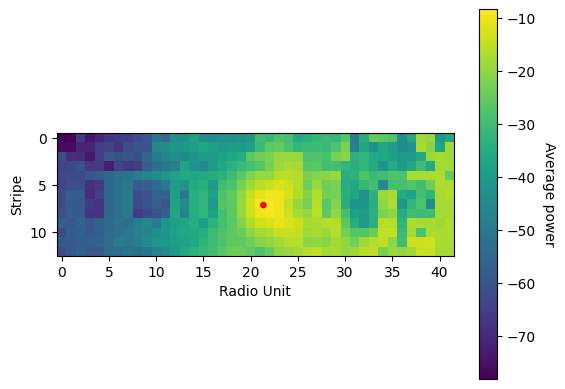

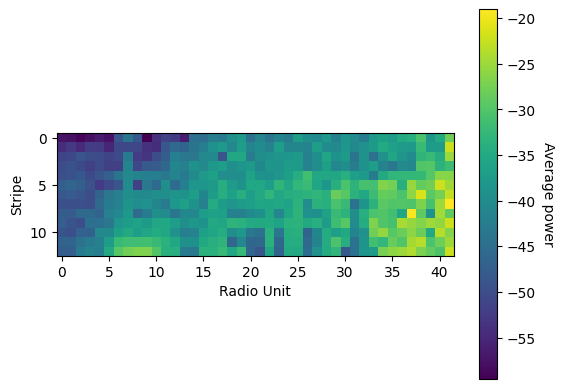

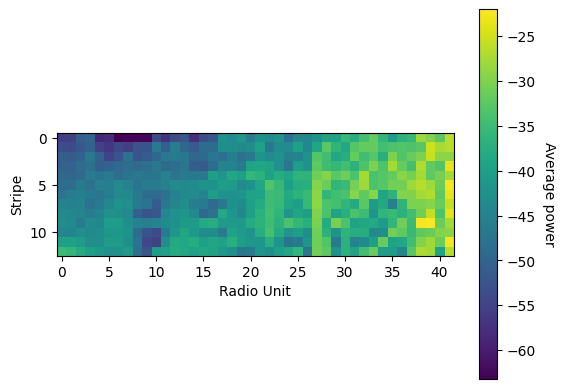

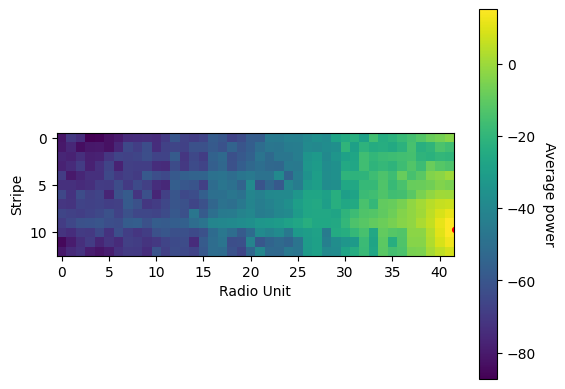

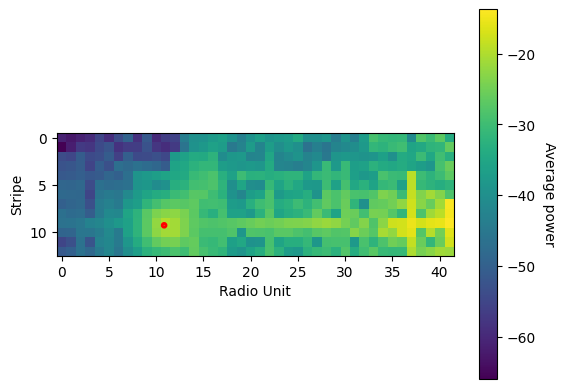

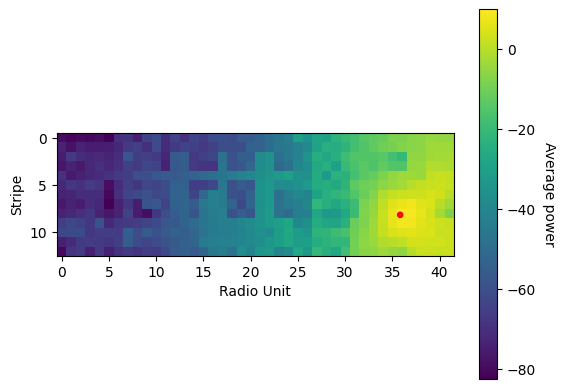

In [18]:
ue_ds = xr.load_dataset("configurations/ue_locations_5681.nc")

for i in range(6):
    user = ue_ds.where(ue_ds["user_id"] == i, drop=True)
    x = float(user["x"])
    y = float(user["y"])
    z = float(user["z"])

    # Read in the data for UEx
    df = pd.read_pickle(f"simulations/flickering_data_{i}.pkl")

    # Make a plot for every UE. The plot is a heatmap with the data for every stripe on the y-axis and the data for every
    # RU on the x-axis.
    fig, ax = plt.subplots()
    data = np.zeros((len(df["stripe_id"].unique()), len(df["ru_id"].unique())))
    for stripe_idx in df["stripe_id"].unique():
        # Get the data for this specific stripe.
        stripe_data = df.loc[df["stripe_id"] == stripe_idx,:]

        # Now iterate over all the data from the different RUs and calculate the pavg.
        for idx, rdata in stripe_data.iterrows():
            pavg = np.mean(np.abs(rdata["data"]) ** 2)
            pavg = 10 * np.log10(pavg / 1e-3)

            data[stripe_idx, rdata["ru_id"]] = pavg
        
    im = ax.imshow(data)
    circle = Circle(((y-2.5) * 2, (x-2.0) * 2), radius=0.2, edgecolor='red', facecolor='none', linewidth=2)
    ax.add_patch(circle)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel("Average power", rotation=-90, va="bottom")

    ax.set_ylabel("Stripe")
    ax.set_xlabel("Radio Unit")